# nuReasoning Reasoning Clip Viewer

Jupyter notebook for viewing reasoning annotations with synchronized camera frames.

The visualization shows Driving and Counterfactual reasoning text above left/front/right camera images. For each selected reasoning frame, the rendered video includes history frames, a paused reasoning frame with spatial object boxes, and future frames with the same reasoning context.

In [6]:
# Configuration
# Set CLIP_DIR to one clip folder containing metadata.json.
CLIP_DIR = "/home/etri/DATASET/nureasoning/clips/2023.07.31.23.53.58_KMHKM4AEXM1P98033_169ca87cd5ca5fdb912f770aa679edd7"
OUTPUT_DIR = "./nureasoning_viz"

# Rendering controls
FPS = 10
HISTORY_SECONDS = 5
FUTURE_SECONDS = 5
PAUSE_SECONDS = 3
TARGET_REASONING_FRAME_INDEXES = {50, 100, 150}

## Install Packages

Run this cell if the imports below are missing in your notebook environment.

In [7]:
import importlib.util
import subprocess
import sys

REQUIRED_PACKAGES = {
    "cv2": "opencv-python",
    "numpy": "numpy",
    "PIL": "pillow",
}

missing_packages = [package for module, package in REQUIRED_PACKAGES.items() if importlib.util.find_spec(module) is None]
if missing_packages:
    subprocess.check_call([sys.executable, "-m", "pip", "install", *missing_packages])
else:
    print("All required packages are already installed.")

All required packages are already installed.


## Visualization Code

Run this cell to define the rendering and data loading helpers.

In [8]:
import json
import os
import pickle
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.animation import FFMpegWriter
from PIL import Image, ImageDraw, ImageFont

FRAME_W = 2880
CAM_W = FRAME_W // 3
CAM_H = int(round(CAM_W * 1856 / 2816))
CAM_PAD_T = 16
CAM_PAD_B = 38
CAM_SEC_H = CAM_PAD_T + CAM_H + CAM_PAD_B

TEXT_H = 900
COL_W = FRAME_W // 2
FRAME_H = TEXT_H + CAM_SEC_H

BG_RGB = (18, 18, 18)
TEXT_RGB = (235, 235, 235)
HEADING_RGB = (100, 220, 255)
SUBHEAD_RGB = (255, 200, 70)
SAFE_RGB = (90, 255, 120)
UNSAFE_RGB = (255, 90, 90)
SUBOPT_RGB = (255, 195, 80)
DIM_RGB = (185, 185, 185)
COMP_RGB = (160, 220, 160)
DIV_RGB = (65, 65, 65)
VEL_BGR = (255, 220, 80)
ACCEL_BGR = (60, 220, 60)
DECEL_BGR = (60, 60, 255)
BG_BGR = (18, 18, 18)
DIV_BGR = (65, 65, 65)
CATEGORY_COLORS_BGR = {
    "car": (40, 220, 255),
    "vehicle.car": (40, 220, 255),
    "truck": (70, 255, 120),
    "vehicle.truck": (70, 255, 120),
    "bus": (255, 180, 60),
    "vehicle.bus": (255, 180, 60),
    "pedestrian": (255, 90, 180),
    "human.pedestrian": (255, 90, 180),
    "bicycle": (180, 130, 255),
    "vehicle.bicycle": (180, 130, 255),
    "motorcycle": (120, 200, 255),
    "vehicle.motorcycle": (120, 200, 255),
    "road obstacle": (70, 190, 255),
    "construction.traffic_cone": (70, 190, 255),
}
DEFAULT_BOX_COLOR_BGR = (235, 235, 235)

_F_REG = "DejaVuSans.ttf"
_F_BOLD = "DejaVuSans-Bold.ttf"


def _font(size: int, bold: bool = False) -> ImageFont.FreeTypeFont:
    try:
        return ImageFont.truetype(_F_BOLD if bold else _F_REG, size)
    except OSError:
        return ImageFont.load_default()


fT = _font(44, bold=True)
fS = _font(32, bold=True)
fB = _font(26)
fSm = _font(22)


def _lh(font: ImageFont.FreeTypeFont) -> int:
    bb = font.getbbox("Ag")
    return (bb[3] - bb[1]) + 5


def _wrap(text: str, font: ImageFont.FreeTypeFont, max_w: int, draw: ImageDraw.ImageDraw) -> list[str]:
    words = str(text).split()
    lines, cur = [], []
    for w in words:
        probe = " ".join(cur + [w])
        if draw.textlength(probe, font=font) <= max_w:
            cur.append(w)
        else:
            if cur:
                lines.append(" ".join(cur))
            cur = [w]
    if cur:
        lines.append(" ".join(cur))
    return lines or [""]


class _SafeUnpickler(pickle.Unpickler):
    def find_class(self, module, name):
        return type(name, (), {
            "__repr__": lambda self: f"<{module}.{name}>",
            "__init__": lambda self, **kw: self.__dict__.update(kw),
        })


def _obj_to_dict(obj):
    if hasattr(obj, "__dict__"):
        return {k: _obj_to_dict(v) for k, v in obj.__dict__.items()}
    if isinstance(obj, dict):
        return {k: _obj_to_dict(v) for k, v in obj.items()}
    if isinstance(obj, (list, tuple)):
        return [_obj_to_dict(v) for v in obj]
    return obj


def load_ego_state(pkl_path: str) -> dict:
    try:
        with open(pkl_path, "rb") as f:
            obj = _SafeUnpickler(f).load()
        return _obj_to_dict(obj)
    except Exception:
        return {}


def _render_column(img: Image.Image, x0: int, section_w: int, title: str, content_fn) -> None:
    draw = ImageDraw.Draw(img)
    M = 22
    max_w = section_w - 2 * M
    x = x0 + M
    y_ref = [16]

    def put(text: str, font=fB, color=TEXT_RGB, indent: int = 0, sp: int = 3):
        for line in _wrap(text, font, max_w - indent, draw):
            if y_ref[0] + _lh(font) + 4 > TEXT_H - 4:
                return
            draw.text((x + indent, y_ref[0]), line, font=font, fill=color)
            y_ref[0] += _lh(font) + sp

    def gap(px: int = 8):
        y_ref[0] += px

    def sep():
        yy = y_ref[0] + 3
        draw.line([(x, yy), (x0 + section_w - M, yy)], fill=DIV_RGB, width=1)
        y_ref[0] += 12

    put(title, font=fT, color=HEADING_RGB)
    sep()
    content_fn(draw, put, gap, sep)


def _driving_content(driving: dict):
    def fn(draw, put, gap, sep):
        scene = driving.get("Scene description", "")
        if scene:
            put("Scene", font=fS, color=SUBHEAD_RGB)
            put(scene, indent=14)
            gap()

        comps = driving.get("Critical components", {})
        if comps:
            put("Critical Components", font=fS, color=SUBHEAD_RGB)
            for name, info in comps.items():
                ctype = info.get("Type", "")
                header = f"* {name}" + (f"  [{ctype}]" if ctype else "")
                put(header, color=COMP_RGB, indent=12)
                for k, v in info.items():
                    if k == "Type":
                        continue
                    put(f"{k}: {v}", font=fSm, color=DIM_RGB, indent=26)
            gap()

        decision = driving.get("Driving decision", {})
        if decision:
            put("Decision", font=fS, color=SUBHEAD_RGB)
            put(f"Longitudinal:  {decision.get('Longitudinal', '')}", color=SAFE_RGB, indent=14)
            put(f"Lateral:       {decision.get('Lateral', '')}", color=SAFE_RGB, indent=14)
            gap()

        trace = driving.get("Reasoning trace", "")
        if trace:
            put("Reasoning Trace", font=fS, color=SUBHEAD_RGB)
            put(trace, indent=14)

    return fn


def _counterfactual_content(cf: dict):
    def fn(draw, put, gap, sep):
        alt = cf.get("Alternative actions", [])
        if alt:
            put("Alternative Actions", font=fS, color=SUBHEAD_RGB)
            for action in alt:
                risk = action.get("Risk level", "")
                rl = risk.lower()
                color = SAFE_RGB if "safe" in rl and "unsafe" not in rl else (
                    SUBOPT_RGB if "suboptimal" in rl else UNSAFE_RGB
                )
                put(f"* {action.get('Longitudinal','')} / {action.get('Lateral','')}   [{risk}]", color=color, indent=12)
                reason = action.get("Reason", "")
                if reason:
                    put(reason, font=fSm, color=DIM_RGB, indent=28)
            gap()

        top = cf.get("Top safety-critical actions", [])
        if top:
            put("Safety-Critical Actions", font=fS, color=SUBHEAD_RGB)
            for action in top:
                risk = action.get("Risk level", "")
                rl = risk.lower()
                color = UNSAFE_RGB if "unsafe" in rl else (SUBOPT_RGB if "suboptimal" in rl else SAFE_RGB)
                put(f"* {action.get('Longitudinal','')} / {action.get('Lateral','')}   [{risk}]", color=color, indent=12)
                reason = action.get("Reason", "")
                if reason:
                    put(reason, font=fSm, color=DIM_RGB, indent=28)
            gap()

    return fn


def render_top_section(driving: dict | None, counterfactual: dict | None, status: str = "") -> np.ndarray:
    img = Image.new("RGB", (FRAME_W, TEXT_H), BG_RGB)
    draw = ImageDraw.Draw(img)
    draw.line([(COL_W, 0), (COL_W, TEXT_H)], fill=DIV_RGB, width=2)
    if status:
        banner_color = SAFE_RGB if status.startswith("NEW") else DIM_RGB
        tw = draw.textlength(status, font=fSm)
        draw.rounded_rectangle((FRAME_W - tw - 54, 16, FRAME_W - 22, 54), radius=8, fill=(35, 35, 35), outline=banner_color, width=2)
        draw.text((FRAME_W - tw - 38, 23), status, font=fSm, fill=banner_color)

    if driving or counterfactual:
        _render_column(img, 0, COL_W, "DRIVING", _driving_content(driving or {}))
        _render_column(img, COL_W, COL_W, "COUNTERFACTUAL", _counterfactual_content(counterfactual or {}))
    else:
        message = "Digesting data for reasoning..."
        for x0, title in ((0, "DRIVING"), (COL_W, "COUNTERFACTUAL")):
            M = 22
            draw.text((x0 + M, 16), title, font=fT, fill=HEADING_RGB)
            sep_y = 16 + _lh(fT) + 6
            draw.line([(x0 + M, sep_y), (x0 + COL_W - M, sep_y)], fill=DIV_RGB, width=1)
            tw = draw.textlength(message, font=fS)
            th = fS.getbbox(message)[3] - fS.getbbox(message)[1]
            draw.text((x0 + (COL_W - tw) / 2, (TEXT_H - th) / 2), message, font=fS, fill=DIM_RGB)

    return cv2.cvtColor(np.array(img), cv2.COLOR_RGB2BGR)


def load_cam(base_dir: str, rel_path: str) -> np.ndarray:
    if not rel_path:
        return np.zeros((CAM_H, CAM_W, 3), dtype=np.uint8)
    img = cv2.imread(os.path.join(base_dir, rel_path))
    if img is None:
        return np.zeros((CAM_H, CAM_W, 3), dtype=np.uint8)
    return cv2.resize(img, (CAM_W, CAM_H), interpolation=cv2.INTER_AREA)


def load_annotation(clip_dir: str, frame: dict) -> dict:
    ann_rel = frame.get("annotations", "")
    if not ann_rel:
        return {}
    ann_path = os.path.join(clip_dir, ann_rel)
    if not os.path.exists(ann_path):
        return {}
    try:
        with open(ann_path, "rb") as f:
            obj = _SafeUnpickler(f).load()
        return _obj_to_dict(obj)
    except Exception:
        return {}


def annotation_by_track_token(annotation: dict) -> dict:
    return {
        obj.get("track_token"): obj
        for obj in annotation.get("objects", [])
        if isinstance(obj, dict) and obj.get("track_token")
    }


def _category_key(obj: dict) -> str:
    return str(obj.get("detection_label") or obj.get("category") or "object").lower()


def _box_color(obj: dict) -> tuple[int, int, int]:
    category = _category_key(obj)
    if category in CATEGORY_COLORS_BGR:
        return CATEGORY_COLORS_BGR[category]
    for key, color in CATEGORY_COLORS_BGR.items():
        if key in category:
            return color
    return DEFAULT_BOX_COLOR_BGR


def _annotation_lines(obj: dict, annotation_lookup: dict) -> list[str]:
    ann = annotation_lookup.get(obj.get("track_token"), {})
    velocity = ann.get("velocity", {})
    label = str(obj.get("detection_label") or obj.get("category") or "object")[:28]
    lines = [label]
    if obj.get("detection_bbox_3d", {}).get("center_3d_ego"):
        center = obj["detection_bbox_3d"]["center_3d_ego"]
        lines.append(f"ego x={center.get('x', 0.0):.1f}, y={center.get('y', 0.0):.1f}")
    if velocity:
        lines.append(f"vx={velocity.get('vx', 0.0):.2f}, vy={velocity.get('vy', 0.0):.2f}")
    return lines


def _spatial_summary_line(number: int, obj: dict, annotation_lookup: dict) -> tuple[str, tuple[int, int, int]]:
    ann = annotation_lookup.get(obj.get("track_token"), {})
    pose = ann.get("pose", {})
    velocity = ann.get("velocity", {})
    center = obj.get("detection_bbox_3d", {}).get("center_3d_ego", {})
    x = pose.get("x", center.get("x", 0.0))
    y = pose.get("y", center.get("y", 0.0))
    vx = velocity.get("vx", 0.0)
    vy = velocity.get("vy", 0.0)
    label = str(obj.get("detection_label") or obj.get("category") or "object")[:14]
    return f"{number}. {label:<14} x={x:8.1f} y={y:8.1f}  vx={vx:6.2f} vy={vy:6.2f}", _box_color(obj)


def _draw_spatial_legend(tile: np.ndarray, lines: list[tuple[str, tuple[int, int, int]]]) -> None:
    if not lines:
        return
    max_lines = min(len(lines), 8)
    x0, y0 = 14, 14
    row_h = 25
    panel_w = 600
    panel_h = 42 + max_lines * row_h
    overlay = tile.copy()
    cv2.rectangle(overlay, (x0, y0), (x0 + panel_w, y0 + panel_h), (0, 0, 0), -1)
    cv2.addWeighted(overlay, 0.58, tile, 0.42, 0, tile)
    cv2.rectangle(tile, (x0, y0), (x0 + panel_w, y0 + panel_h), DIV_BGR, 1)
    cv2.putText(tile, "Spatial objects: x/y position, vx/vy velocity", (x0 + 12, y0 + 25), cv2.FONT_HERSHEY_SIMPLEX, 0.58, (230, 230, 230), 1, cv2.LINE_AA)
    for i, (text, color) in enumerate(lines[:max_lines]):
        yy = y0 + 53 + i * row_h
        cv2.putText(tile, text, (x0 + 12, yy), cv2.FONT_HERSHEY_SIMPLEX, 0.54, (0, 0, 0), 3, cv2.LINE_AA)
        cv2.putText(tile, text, (x0 + 12, yy), cv2.FONT_HERSHEY_SIMPLEX, 0.54, color, 1, cv2.LINE_AA)


def _rects_overlap(a: tuple[int, int, int, int], b: tuple[int, int, int, int]) -> bool:
    return not (a[2] < b[0] or b[2] < a[0] or a[3] < b[1] or b[3] < a[1])


def _choose_label_position(
    x1: int,
    y1: int,
    x2: int,
    label_w: int,
    label_h: int,
    occupied: list[tuple[int, int, int, int]],
) -> tuple[int, int, int, int]:
    margin = 8
    right_x = x2 + margin
    left_x = x1 - label_w - margin
    x_options = []
    if right_x + label_w < CAM_W:
        x_options.append(right_x)
    if left_x >= 0:
        x_options.append(left_x)
    if not x_options:
        x_options.append(max(0, min(CAM_W - label_w - 1, right_x)))

    offsets = [0]
    for step in range(1, 10):
        delta = step * (label_h + 8)
        offsets.extend([-delta, delta])

    for lx in x_options:
        for offset in offsets:
            ly = max(0, min(CAM_H - label_h - 1, y1 + offset))
            rect = (lx, ly, lx + label_w, ly + label_h)
            if not any(_rects_overlap(rect, prev) for prev in occupied):
                return rect
    lx = x_options[0]
    ly = max(0, min(CAM_H - label_h - 1, y1))
    return (lx, ly, lx + label_w, ly + label_h)


def _draw_box_label(
    tile: np.ndarray,
    x1: int,
    y1: int,
    x2: int,
    y2: int,
    lines: list[str],
    color: tuple[int, int, int],
    occupied: list[tuple[int, int, int, int]],
) -> None:
    if not lines:
        return
    lf = cv2.FONT_HERSHEY_SIMPLEX
    scale = 0.52
    thick = 1
    row_h = 22
    pad = 4
    text_sizes = [cv2.getTextSize(line, lf, scale, thick)[0] for line in lines]
    label_w = max(w for w, _ in text_sizes) + pad
    label_h = len(lines) * row_h
    lx, ly, rx, by = _choose_label_position(x1, y1, x2, label_w, label_h, occupied)
    occupied.append((lx, ly, rx, by))
    for i, line in enumerate(lines):
        yy = ly + 16 + i * row_h
        cv2.putText(tile, line, (lx + pad + 1, yy + 1), lf, scale, (0, 0, 0), thick + 2, cv2.LINE_AA)
        cv2.putText(tile, line, (lx + pad, yy), lf, scale, color, thick, cv2.LINE_AA)


def _draw_object_boxes(tile: np.ndarray, camera_reasoning: dict, annotation_lookup: dict) -> None:
    occupied_labels = []
    for idx, obj in enumerate(camera_reasoning.get("objects", [])):
        bbox = obj.get("detection_bbox_2d")
        if not isinstance(bbox, list) or len(bbox) != 4:
            continue
        x1, y1, x2, y2 = bbox
        sx = CAM_W / 2816.0
        sy = CAM_H / 1856.0
        x1, x2 = int(round(x1 * sx)), int(round(x2 * sx))
        y1, y2 = int(round(y1 * sy)), int(round(y2 * sy))
        x1, x2 = max(0, min(CAM_W - 1, x1)), max(0, min(CAM_W - 1, x2))
        y1, y2 = max(0, min(CAM_H - 1, y1)), max(0, min(CAM_H - 1, y2))
        if x2 <= x1 or y2 <= y1:
            continue
        color = _box_color(obj)
        cv2.rectangle(tile, (x1, y1), (x2, y2), color, 3)
        _draw_box_label(tile, x1, y1, x2, y2, _annotation_lines(obj, annotation_lookup), color, occupied_labels)


def _overlay_ego(canvas: np.ndarray, cam_x: int, cam_y: int, cam_w: int, cam_h: int, ego: dict) -> None:
    vel = ego.get("velocity", {})
    acc = ego.get("acceleration", {})
    lf = cv2.FONT_HERSHEY_SIMPLEX
    scale = 1.1
    thick = 2
    lh = 42
    pad = 18

    def _put(text, x, y, color):
        cv2.putText(canvas, text, (x + 2, y + 2), lf, scale, (0, 0, 0), thick + 2, cv2.LINE_AA)
        cv2.putText(canvas, text, (x, y), lf, scale, color, thick, cv2.LINE_AA)

    if vel:
        vx = vel.get("vx", 0.0)
        vy = vel.get("vy", 0.0)
        speed_ms = (vx ** 2 + vy ** 2) ** 0.5
        speed_kph = speed_ms * 3.6
        x0 = cam_x + pad
        y0 = cam_y + pad + int(scale * 28)
        _put("Velocity:", x0, y0, VEL_BGR)
        _put(f"{speed_ms:.2f} m/s", x0, y0 + lh, VEL_BGR)
        _put(f"{speed_kph:.1f} km/h", x0, y0 + 2 * lh, VEL_BGR)

    if acc:
        ax = acc.get("ax", 0.0)
        acc_color = ACCEL_BGR if ax >= 0 else DECEL_BGR
        acc_label = "Accelerating" if ax >= 0 else "Decelerating"
        lines = [acc_label, f"{ax:+.2f} m/s^2"]
        max_tw = max(cv2.getTextSize(line, lf, scale, thick)[0][0] for line in lines)
        x0 = cam_x + cam_w - pad - max_tw
        y0 = cam_y + pad + int(scale * 28)
        for i, line in enumerate(lines):
            tw = cv2.getTextSize(line, lf, scale, thick)[0][0]
            _put(line, x0 + (max_tw - tw), y0 + i * lh, acc_color)


def compose_frame(left, front, right, top_section, frame_num, total_frames, ego_state=None) -> np.ndarray:
    canvas = np.full((FRAME_H, FRAME_W, 3), BG_BGR, dtype=np.uint8)
    canvas[0:TEXT_H, 0:FRAME_W] = top_section
    cv2.line(canvas, (0, TEXT_H), (FRAME_W, TEXT_H), DIV_BGR, 3)
    cam_y = TEXT_H + CAM_PAD_T
    canvas[cam_y:cam_y + CAM_H, 0:CAM_W] = left
    canvas[cam_y:cam_y + CAM_H, CAM_W:2 * CAM_W] = front
    canvas[cam_y:cam_y + CAM_H, 2 * CAM_W:3 * CAM_W] = right
    if ego_state:
        _overlay_ego(canvas, CAM_W, cam_y, CAM_W, CAM_H, ego_state)
    for x_div in (CAM_W, 2 * CAM_W):
        cv2.line(canvas, (x_div, cam_y), (x_div, cam_y + CAM_H), DIV_BGR, 2)
    label_y = cam_y + CAM_H + 22
    lf = cv2.FONT_HERSHEY_SIMPLEX
    for label, cx in [("LEFT", CAM_W // 2), ("FRONT", CAM_W + CAM_W // 2), ("RIGHT", 2 * CAM_W + CAM_W // 2)]:
        tw = cv2.getTextSize(label, lf, 0.9, 2)[0][0]
        cv2.putText(canvas, label, (cx - tw // 2, label_y), lf, 0.9, (170, 170, 170), 2, cv2.LINE_AA)
    fc_text = f"{frame_num + 1} / {total_frames}"
    fc_tw = cv2.getTextSize(fc_text, lf, 0.7, 1)[0][0]
    cv2.putText(canvas, fc_text, (FRAME_W - fc_tw - 12, cam_y + 28), lf, 0.7, (120, 120, 120), 1, cv2.LINE_AA)
    return canvas


def load_reasoning(clip_dir: str, frame: dict) -> dict:
    reasoning_rel = frame.get("reasoning", "")
    if not reasoning_rel:
        return {}
    reasoning_path = os.path.join(clip_dir, reasoning_rel)
    if not os.path.exists(reasoning_path):
        return {}
    with open(reasoning_path) as f:
        return json.load(f)


def has_complete_reasoning(rjson: dict) -> bool:
    driving = rjson.get("Driving", "")
    counterfactual = rjson.get("Counterfactual", "")
    if not isinstance(driving, dict) or not driving.get("Driving decision"):
        return False
    if not isinstance(counterfactual, dict) or not counterfactual:
        return False
    return True


def frame_reasoning_sections(rjson: dict) -> tuple[dict, dict, dict, bool]:
    if not has_complete_reasoning(rjson):
        return {}, {}, {}, False
    return (
        rjson.get("Driving", {}),
        rjson.get("Counterfactual", {}),
        rjson.get("Spatial", {}).get("per_camera_results", {}),
        True,
    )


def write_visual_frame(
    writer,
    clip_dir: str,
    cf: dict,
    frame_num: int,
    total_frames: int,
    display_reasoning: tuple[dict, dict] | None,
    status: str,
    repeats: int,
    per_camera: dict | None = None,
    draw_boxes: bool = False,
) -> None:
    display_driving, display_counterfactual = display_reasoning if display_reasoning else ({}, {})
    top_section = render_top_section(display_driving, display_counterfactual, status)
    ego_pkl_rel = cf.get("ego_state", "")
    ego_state = load_ego_state(os.path.join(clip_dir, ego_pkl_rel)) if ego_pkl_rel else {}
    annotation_lookup = annotation_by_track_token(load_annotation(clip_dir, cf)) if draw_boxes else {}
    cams = cf.get("sensors", {}).get("cameras", {})
    left_img = load_cam(clip_dir, cams.get("front_left", ""))
    front_img = load_cam(clip_dir, cams.get("front", ""))
    right_img = load_cam(clip_dir, cams.get("front_right", ""))
    if draw_boxes and per_camera:
        _draw_object_boxes(left_img, per_camera.get("front_left", {}), annotation_lookup)
        _draw_object_boxes(front_img, per_camera.get("front", {}), annotation_lookup)
        _draw_object_boxes(right_img, per_camera.get("front_right", {}), annotation_lookup)
    composed = compose_frame(left_img, front_img, right_img, top_section, frame_num, total_frames, ego_state)
    for _ in range(repeats):
        writer.write(composed)


def _frame_time(frame: dict, fallback_idx: int, source_fps: float) -> float:
    if "relative_time_s" in frame:
        return float(frame["relative_time_s"])
    return fallback_idx / source_fps


def _source_frame_repeats(source_fps: float) -> int:
    if source_fps <= 0:
        return 1
    return max(1, int(round(FPS / source_fps)))


class _FFMpegArrayWriter:
    def __init__(self, output_path: str, fps: int, dpi: int = 100) -> None:
        self.frame_w = FRAME_W + (FRAME_W % 2)
        self.frame_h = FRAME_H + (FRAME_H % 2)
        self.fig, self.ax = plt.subplots(figsize=(self.frame_w / dpi, self.frame_h / dpi), dpi=dpi, facecolor="black")
        self.fig.subplots_adjust(left=0, right=1, bottom=0, top=1)
        self.ax.axis("off")
        self.image = self.ax.imshow(np.zeros((self.frame_h, self.frame_w, 3), dtype=np.uint8))
        self.writer = FFMpegWriter(
            fps=max(fps, 1),
            codec="libx264",
            extra_args=["-pix_fmt", "yuv420p", "-movflags", "+faststart"],
        )
        self.writer.setup(self.fig, output_path, dpi=dpi)

    def write(self, frame_bgr: np.ndarray) -> None:
        frame_rgb = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2RGB)
        if frame_rgb.shape[:2] != (self.frame_h, self.frame_w):
            padded = np.zeros((self.frame_h, self.frame_w, 3), dtype=np.uint8)
            h = min(frame_rgb.shape[0], self.frame_h)
            w = min(frame_rgb.shape[1], self.frame_w)
            padded[:h, :w] = frame_rgb[:h, :w]
            frame_rgb = padded
        self.image.set_data(frame_rgb)
        self.writer.grab_frame(facecolor=self.fig.get_facecolor())

    def release(self) -> None:
        try:
            self.writer.finish()
        finally:
            plt.close(self.fig)


def _open_video_writer(output_path: str) -> _FFMpegArrayWriter:
    return _FFMpegArrayWriter(output_path, FPS)


def process_clip(clip_dir: str, output_dir: str) -> int:
    meta_path = os.path.join(clip_dir, "metadata.json")
    if not os.path.exists(meta_path):
        return 0
    with open(meta_path) as f:
        meta = json.load(f)
    frames = sorted(meta.get("frames", []), key=lambda fr: fr["frame_index"])
    source_fps = float(meta.get("frame_rate_hz") or 2.0)
    frame_repeats = _source_frame_repeats(source_fps)

    # Find the reasoning frame closest to each target index.
    reasoning_frame_map = {
        i: frame for i, frame in enumerate(frames) if frame.get("reasoning")
    }
    reasoning_indexes = sorted(reasoning_frame_map.keys())
    selected_indexes = set()
    for target in TARGET_REASONING_FRAME_INDEXES:
        if not reasoning_indexes:
            break
        closest = min(reasoning_indexes, key=lambda x: abs(x - target))
        selected_indexes.add(closest)

    written = 0
    for anchor_idx, frame in enumerate(frames):
        reasoning_rel = frame.get("reasoning", "")
        if not reasoning_rel:
            continue
        rjson = load_reasoning(clip_dir, frame)
        reasoning_frame_index = int(rjson.get("frame_index", frame.get("frame_index", -1)))
        if reasoning_frame_index not in selected_indexes:
            continue
        driving, counterfactual, per_camera, complete = frame_reasoning_sections(rjson)
        if not complete:
            continue
        anchor_time = _frame_time(frame, anchor_idx, source_fps)
        history_start = anchor_time - HISTORY_SECONDS
        future_end = anchor_time + FUTURE_SECONDS
        history_frames = [
            (idx, cf)
            for idx, cf in enumerate(frames)
            if history_start <= _frame_time(cf, idx, source_fps) < anchor_time
        ]
        future_frames = [
            (idx, cf)
            for idx, cf in enumerate(frames)
            if anchor_time < _frame_time(cf, idx, source_fps) <= future_end
        ]
        total_source_frames = len(history_frames) + 1 + len(future_frames)
        display_reasoning = (driving, counterfactual)
        clip_frames = history_frames + [(anchor_idx, frame)] + future_frames
        if not clip_frames:
            continue
        output_path = os.path.join(output_dir, f"{Path(reasoning_rel).stem}.mp4")
        if os.path.exists(output_path):
            written += 1
            continue
        writer = _open_video_writer(output_path)
        output_frame_num = 0
        for _, cf in history_frames:
            write_visual_frame(
                writer,
                clip_dir,
                cf,
                output_frame_num,
                total_source_frames,
                None,
                "Digesting data for reasoning...",
                frame_repeats,
            )
            output_frame_num += 1
        write_visual_frame(
            writer,
            clip_dir,
            frame,
            output_frame_num,
            total_source_frames,
            display_reasoning,
            f"REASONING FRAME - PAUSED {PAUSE_SECONDS}s",
            FPS * PAUSE_SECONDS,
            per_camera=per_camera,
            draw_boxes=True,
        )
        output_frame_num += 1
        for _, cf in future_frames:
            write_visual_frame(
                writer,
                clip_dir,
                cf,
                output_frame_num,
                total_source_frames,
                display_reasoning,
                "Future - reasoning unchanged",
                frame_repeats,
            )
            output_frame_num += 1
        writer.release()
        written += 1
    return written

## Notebook Helpers

Use these helpers to load one clip, summarize reasoning frames, preview one frame, and render videos.

In [9]:
def get_clip_dir(clip_dir: str | Path) -> Path:
    clip_path = Path(clip_dir)
    meta_path = clip_path / "metadata.json"
    if not meta_path.exists():
        raise RuntimeError(f"metadata.json not found in clip folder: {clip_path}")
    return clip_path


def load_clip_metadata(clip_dir: str | Path) -> dict:
    meta_path = Path(clip_dir) / "metadata.json"
    if not meta_path.exists():
        return {}
    with open(meta_path, "r", encoding="utf-8") as f:
        return json.load(f)


def reasoning_frame_summaries(clip_dir: str | Path) -> list[dict]:
    clip_dir = Path(clip_dir)
    meta = load_clip_metadata(clip_dir)
    frames = sorted(meta.get("frames", []), key=lambda frame: frame.get("frame_index", 0))
    summaries = []
    for idx, frame in enumerate(frames):
        if not frame.get("reasoning"):
            continue
        rjson = load_reasoning(str(clip_dir), frame)
        driving, counterfactual, per_camera, complete = frame_reasoning_sections(rjson)
        summaries.append(
            {
                "frame_list_index": idx,
                "frame_index": frame.get("frame_index"),
                "reasoning_path": frame.get("reasoning", ""),
                "complete_reasoning": complete,
                "camera_sections": sorted(per_camera.keys()) if isinstance(per_camera, dict) else [],
                "driving_keys": sorted(driving.keys()) if isinstance(driving, dict) else [],
                "counterfactual_keys": sorted(counterfactual.keys()) if isinstance(counterfactual, dict) else [],
            }
        )
    return summaries


def print_clip_overview(clip_dir: str | Path) -> None:
    clip_dir = Path(clip_dir)
    meta = load_clip_metadata(clip_dir)
    frames = meta.get("frames", [])
    reasoning_frames = reasoning_frame_summaries(clip_dir)
    camera_names = sorted(
        {
            camera_name
            for frame in frames
            for camera_name in ((frame.get("sensors", {}) or {}).get("cameras", {}) or {}).keys()
        }
    )
    print(f"Clip: {clip_dir.name}")
    print(f"Frames: {len(frames)}")
    print(f"Frame rate: {meta.get('frame_rate_hz', 'unknown')}")
    print(f"Cameras: {', '.join(camera_names) or 'none'}")
    print(f"Reasoning frames: {len(reasoning_frames)}")
    for summary in reasoning_frames[:10]:
        status = "complete" if summary["complete_reasoning"] else "incomplete"
        print(f"  frame {summary['frame_index']}: {status}  {summary['reasoning_path']}")
    if len(reasoning_frames) > 10:
        print(f"  ... {len(reasoning_frames) - 10} more")


def render_reasoning_clip(clip_dir: str | Path, output_dir: str | Path) -> int:
    clip_dir = get_clip_dir(clip_dir)
    clip_output = Path(output_dir) / clip_dir.name
    clip_output.mkdir(parents=True, exist_ok=True)
    written = process_clip(str(clip_dir), str(clip_output))
    print(f"{clip_dir.name}: {written} file(s) written to {clip_output}")
    return written

## Load Clip

Load the clip folder from `CLIP_DIR` and print its reasoning-frame summary.

In [10]:
clip_dir = get_clip_dir(CLIP_DIR)
print_clip_overview(clip_dir)

Clip: 2023.07.31.23.53.58_KMHKM4AEXM1P98033_169ca87cd5ca5fdb912f770aa679edd7
Frames: 202
Frame rate: 10
Cameras: back, back_left, back_right, front, front_left, front_right, left, right
Reasoning frames: 13
  frame 30: incomplete  reasoning/1690849579699964.json
  frame 40: incomplete  reasoning/1690849580699999.json
  frame 50: complete  reasoning/1690849581699937.json
  frame 60: incomplete  reasoning/1690849582699987.json
  frame 70: incomplete  reasoning/1690849583699964.json
  frame 80: incomplete  reasoning/1690849584699987.json
  frame 90: incomplete  reasoning/1690849585699994.json
  frame 100: complete  reasoning/1690849586599958.json
  frame 110: incomplete  reasoning/1690849587599949.json
  frame 120: incomplete  reasoning/1690849588599979.json
  ... 3 more


## Select Preview Frame

Choose which complete reasoning frame to preview.

In [11]:
# Set to 0 for the first complete reasoning frame, 1 for the second, and so on.
SELECTED_REASONING_INDEX = 0

## Preview One Frame

Render one complete reasoning frame as an image before creating videos.

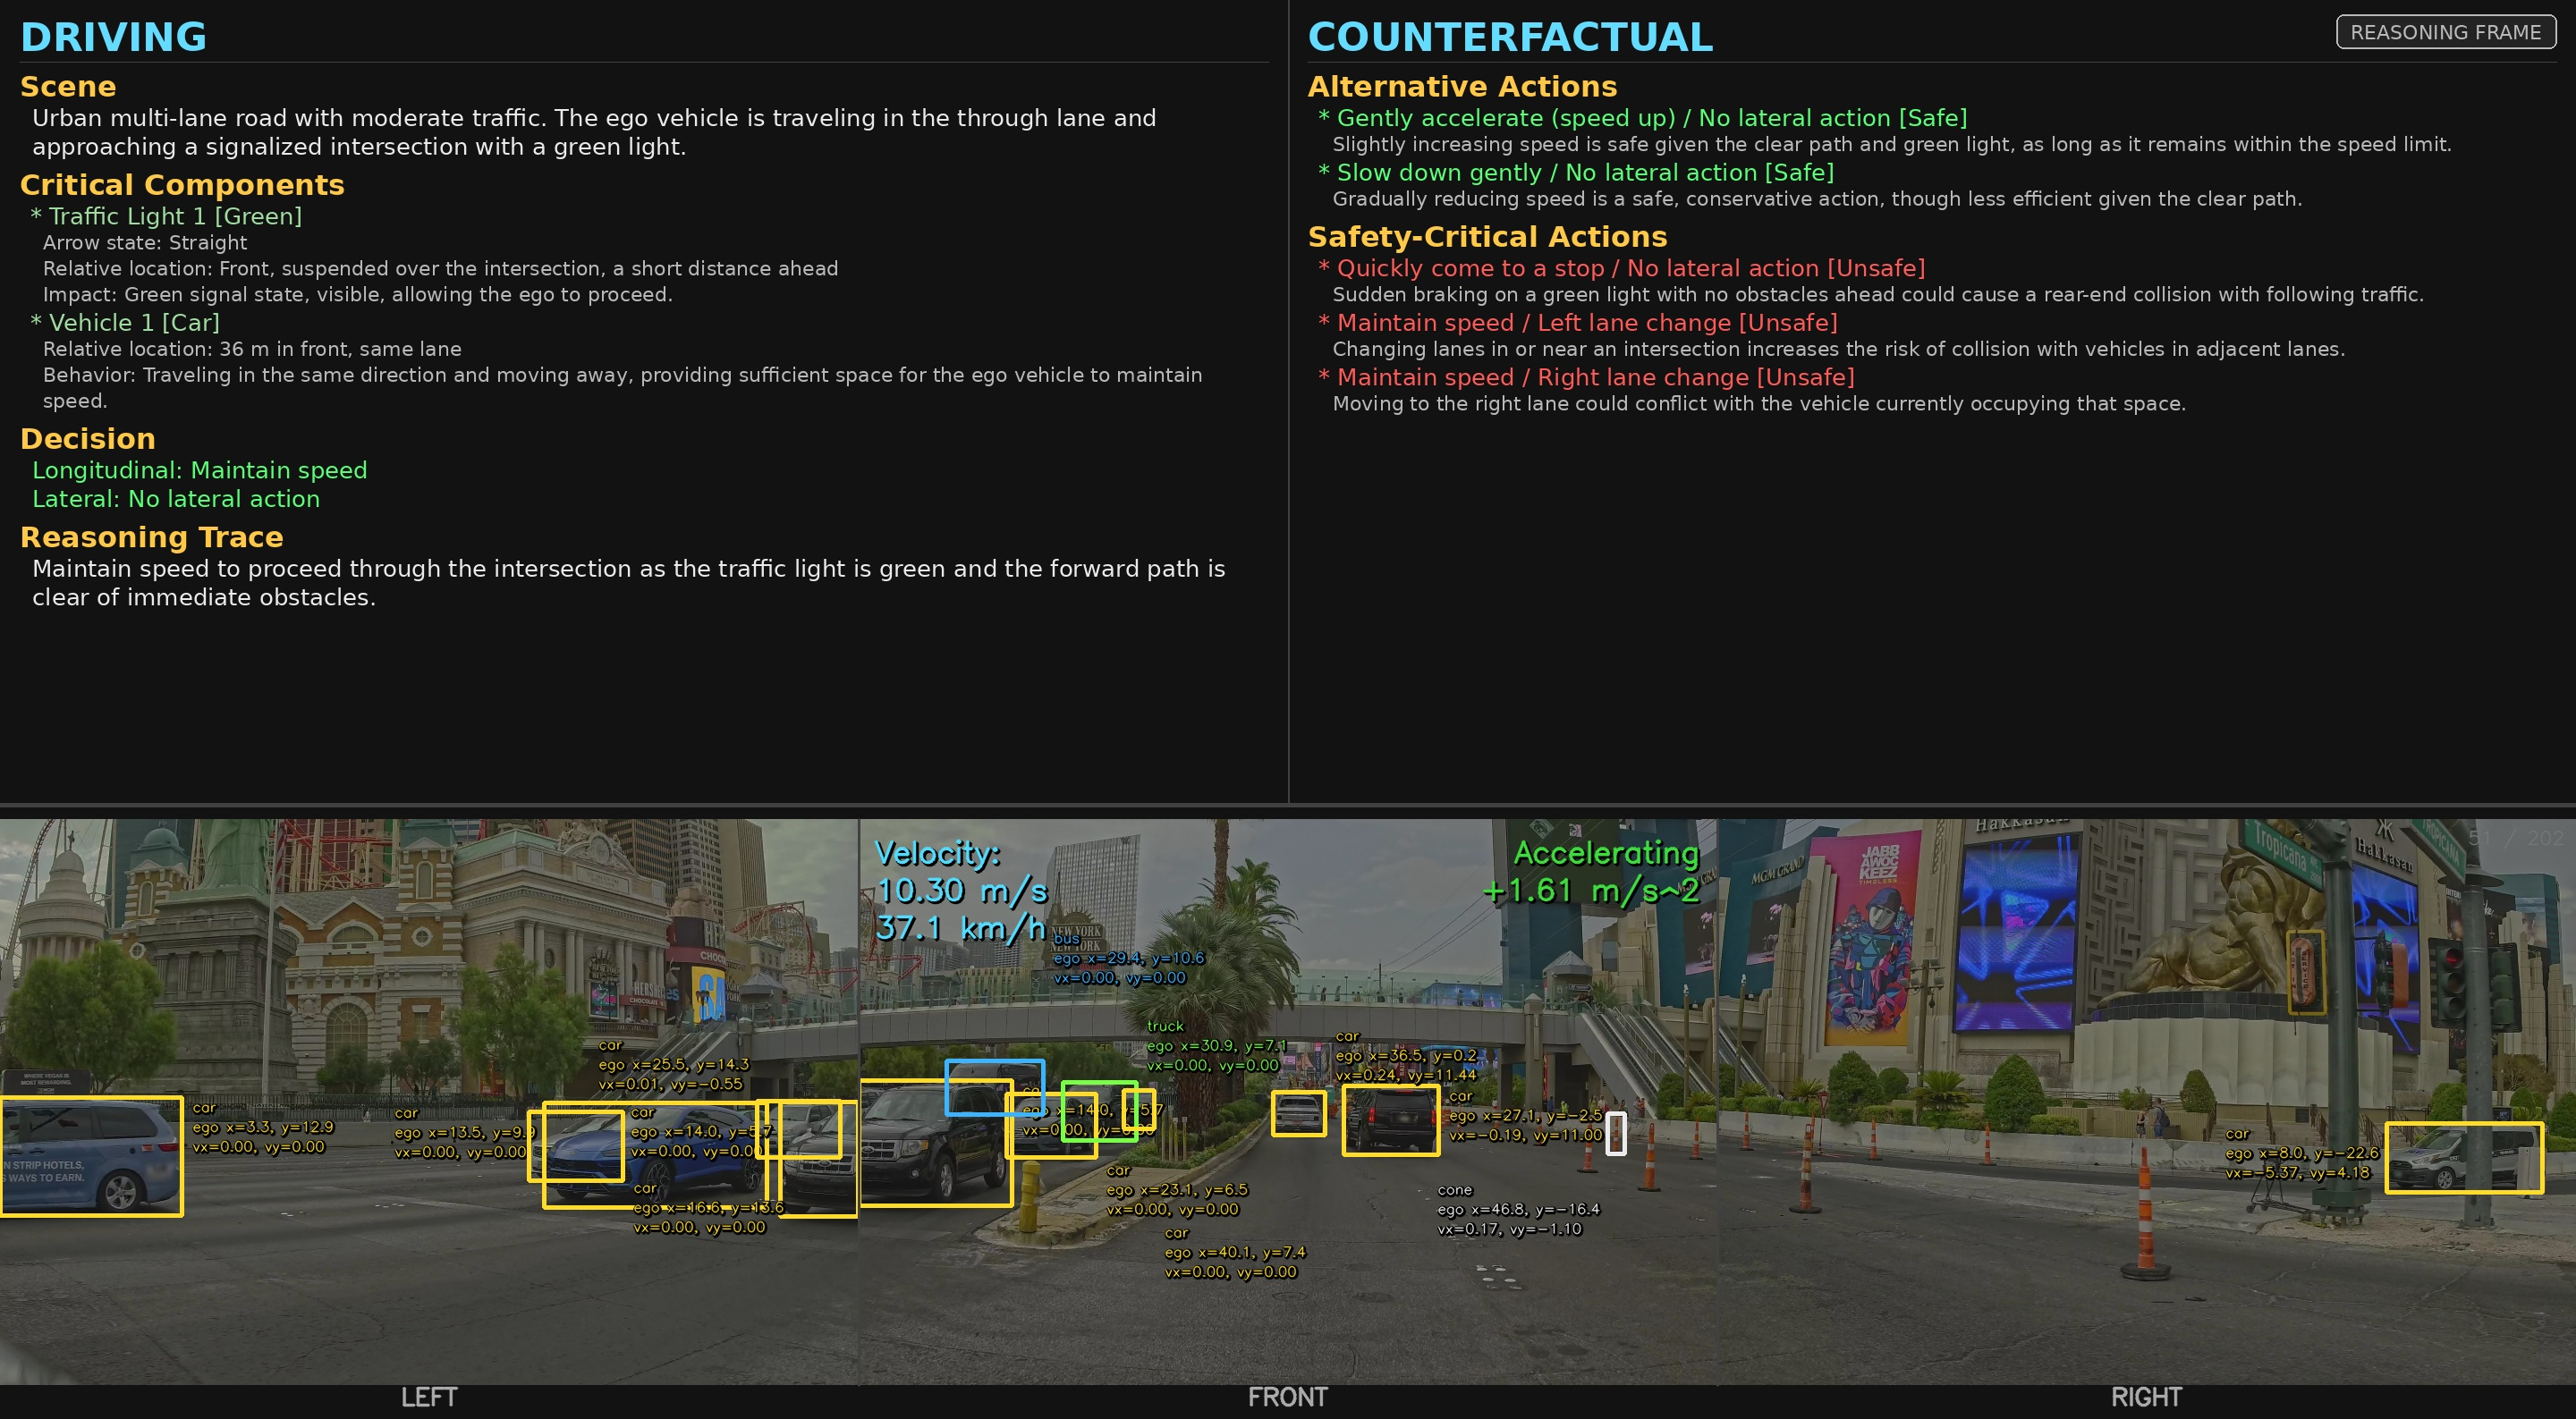

In [12]:
# Preview one composed reasoning frame as an image.
from IPython.display import Image as DisplayImage, display

meta = load_clip_metadata(clip_dir)
frames = sorted(meta.get("frames", []), key=lambda frame: frame.get("frame_index", 0))
complete_frames = []
for idx, frame in enumerate(frames):
    if not frame.get("reasoning"):
        continue
    rjson = load_reasoning(str(clip_dir), frame)
    driving, counterfactual, per_camera, complete = frame_reasoning_sections(rjson)
    if complete:
        complete_frames.append((idx, frame, driving, counterfactual, per_camera))

if not complete_frames:
    print("No complete reasoning frame found for preview.")
elif SELECTED_REASONING_INDEX < 0 or SELECTED_REASONING_INDEX >= len(complete_frames):
    print(f"SELECTED_REASONING_INDEX must be between 0 and {len(complete_frames) - 1}")
else:
    idx, frame, driving, counterfactual, per_camera = complete_frames[SELECTED_REASONING_INDEX]
    top_section = render_top_section(driving, counterfactual, "REASONING FRAME")
    annotation_lookup = annotation_by_track_token(load_annotation(str(clip_dir), frame))
    cameras = frame.get("sensors", {}).get("cameras", {})
    left_img = load_cam(str(clip_dir), cameras.get("front_left", ""))
    front_img = load_cam(str(clip_dir), cameras.get("front", ""))
    right_img = load_cam(str(clip_dir), cameras.get("front_right", ""))
    _draw_object_boxes(left_img, per_camera.get("front_left", {}), annotation_lookup)
    _draw_object_boxes(front_img, per_camera.get("front", {}), annotation_lookup)
    _draw_object_boxes(right_img, per_camera.get("front_right", {}), annotation_lookup)
    ego_rel = frame.get("ego_state", "")
    ego_state = load_ego_state(str(clip_dir / ego_rel)) if ego_rel else {}
    preview = compose_frame(left_img, front_img, right_img, top_section, idx, len(frames), ego_state)
    preview_path = Path(OUTPUT_DIR) / clip_dir.name / "preview_reasoning_frame.jpg"
    preview_path.parent.mkdir(parents=True, exist_ok=True)
    cv2.imwrite(str(preview_path), preview)
    display(DisplayImage(filename=str(preview_path)))

## Render Videos

Create MP4 clips for the selected reasoning frames.

FileNotFoundError: [Errno 2] No such file or directory: 'ffmpeg'

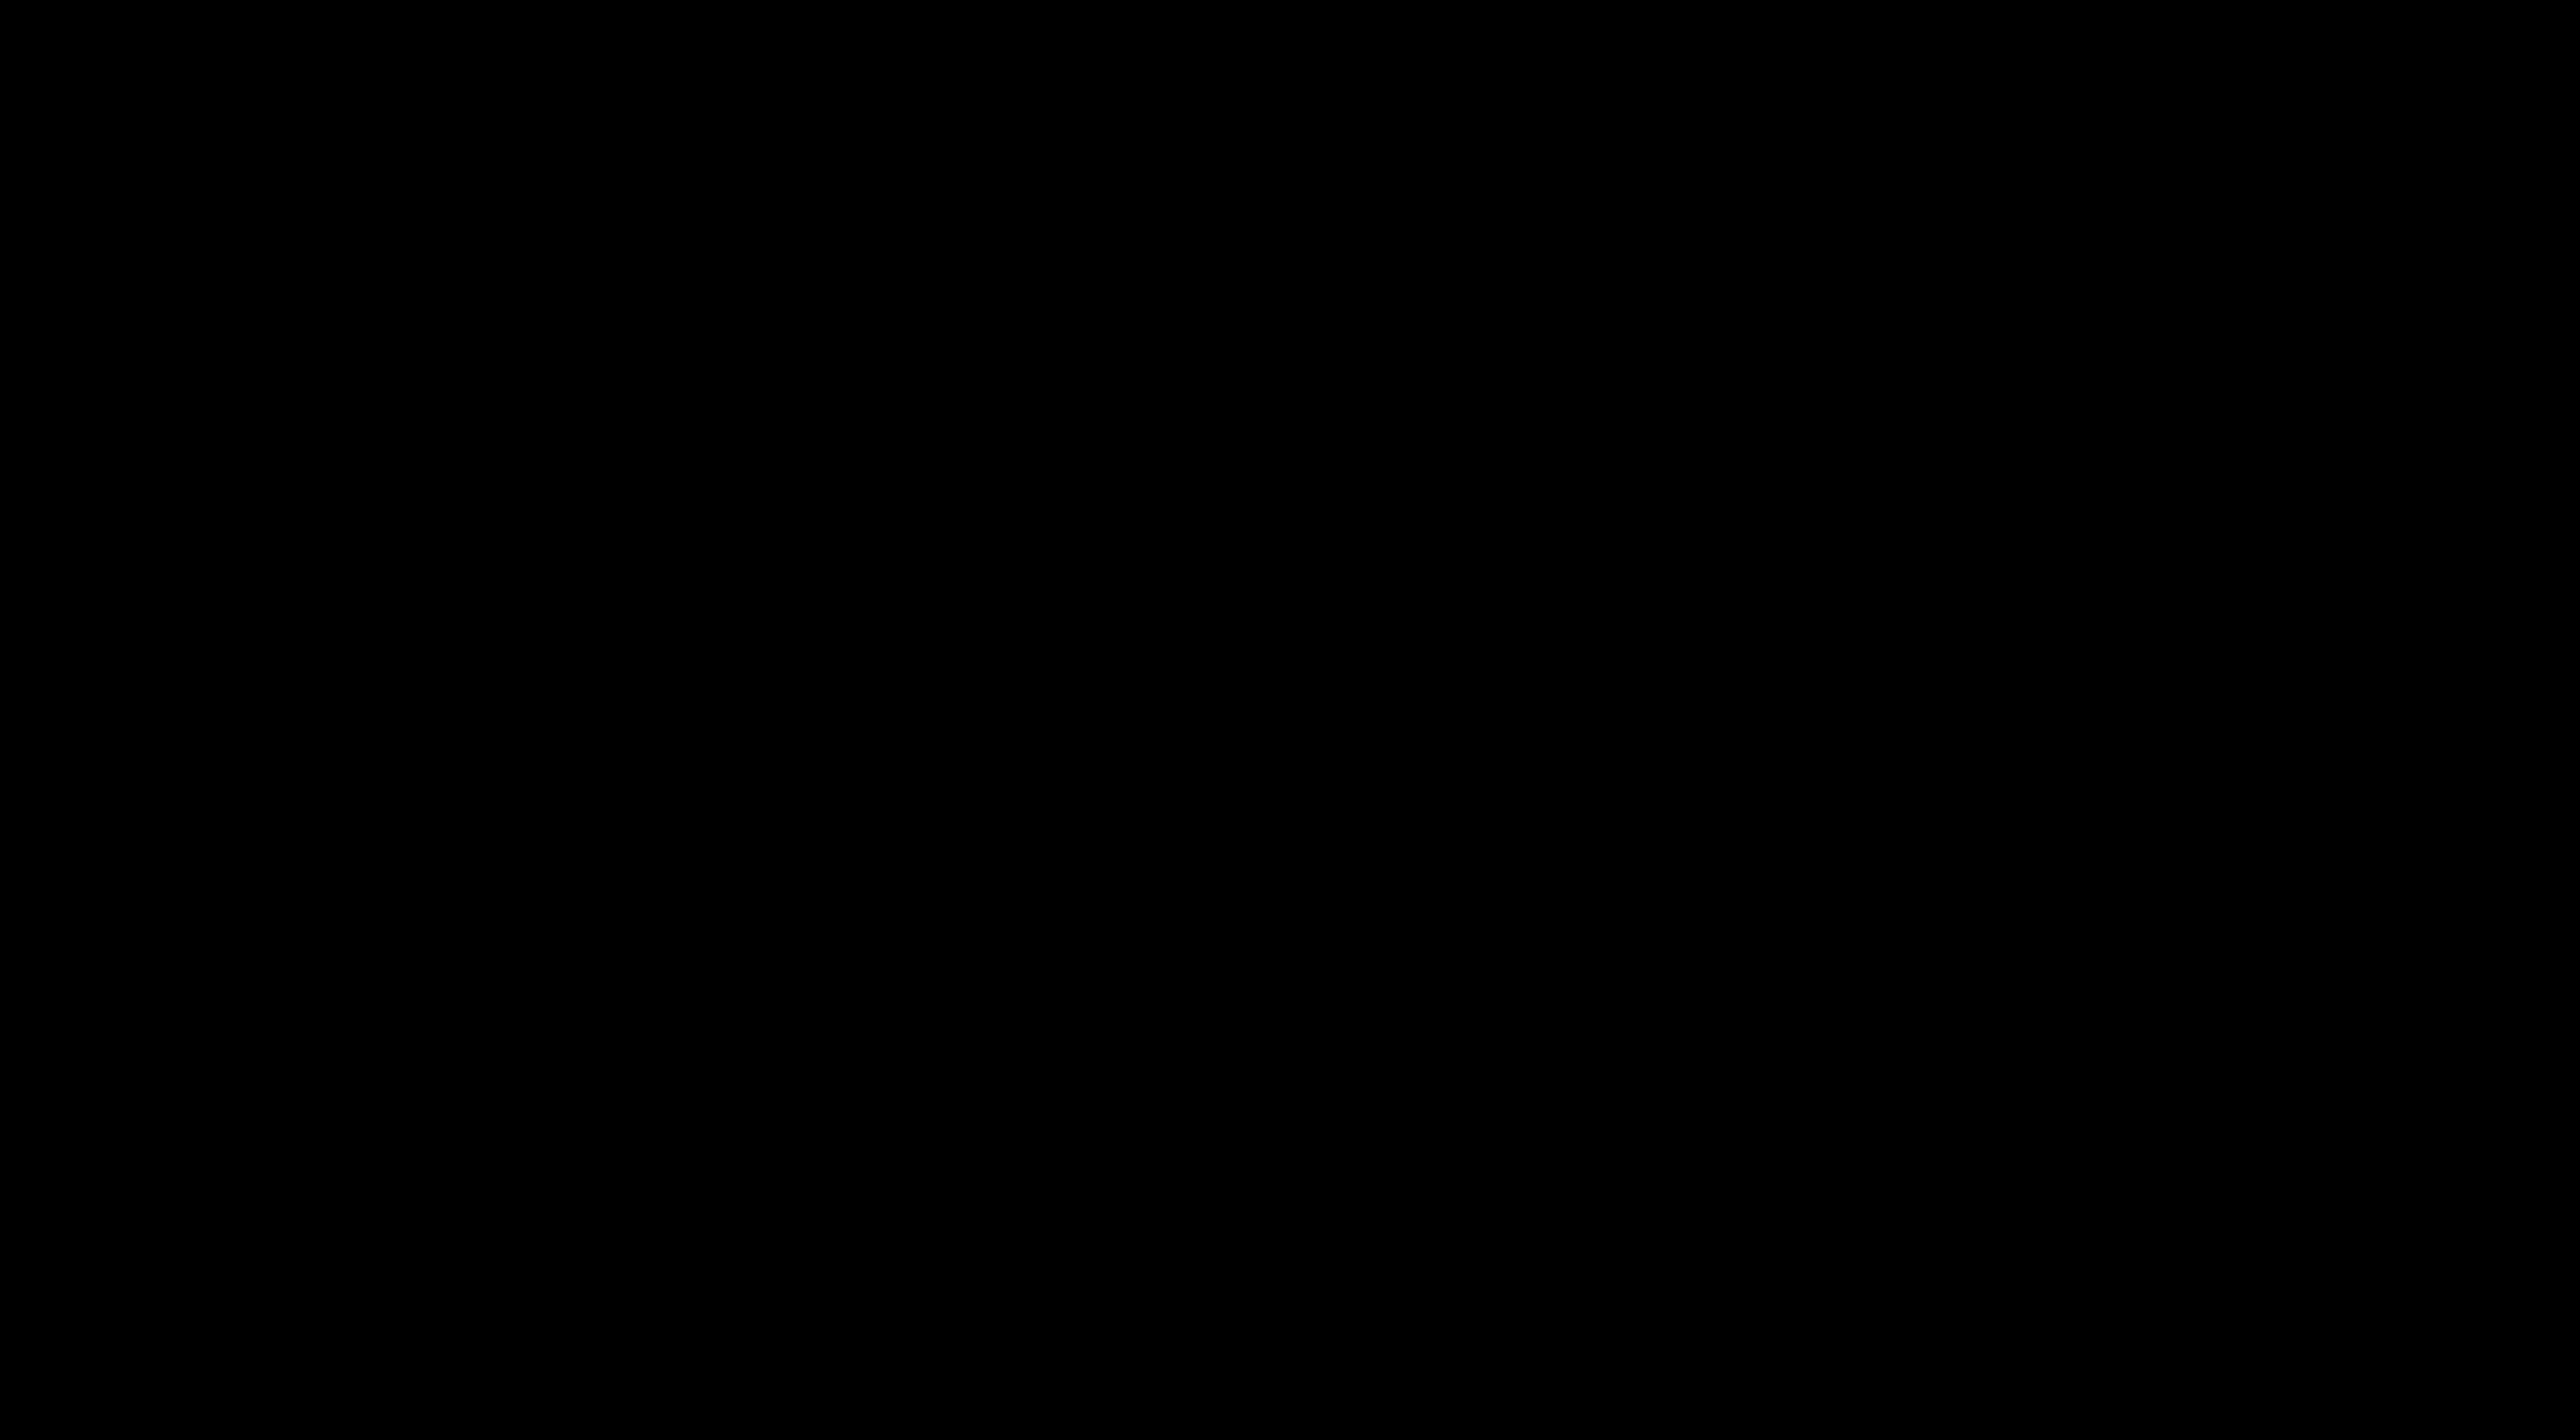

In [13]:
# Render reasoning videos for this clip.
total_written = render_reasoning_clip(clip_dir, OUTPUT_DIR)
print(f"Rendered {total_written} file(s) under {OUTPUT_DIR}")